In [90]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from hmmlearn import hmm

In [91]:
# loading in cleaned data
produce_frame = pd.read_csv("cleaned_produce.csv")

# list of produce
produce_names = produce_frame["productname"].unique()


In [92]:
def make_covar_stationary(data):
    d_best = 0

    # increase difference untill covaraince stationary
    while True:

        # adfuller method uses hypothesis test to see if data is covaraince stationary
        p_value = adfuller(data)[1]

        if p_value < 0.05:
            # it is likely covariance stationary
            return d_best, data
        
        else:
            # not covaraince stationary do increase d by 1
            d_best += 1
            data = np.diff(data, n=d_best)

Exploring HMM states and how well they can differentiate produce seasonality

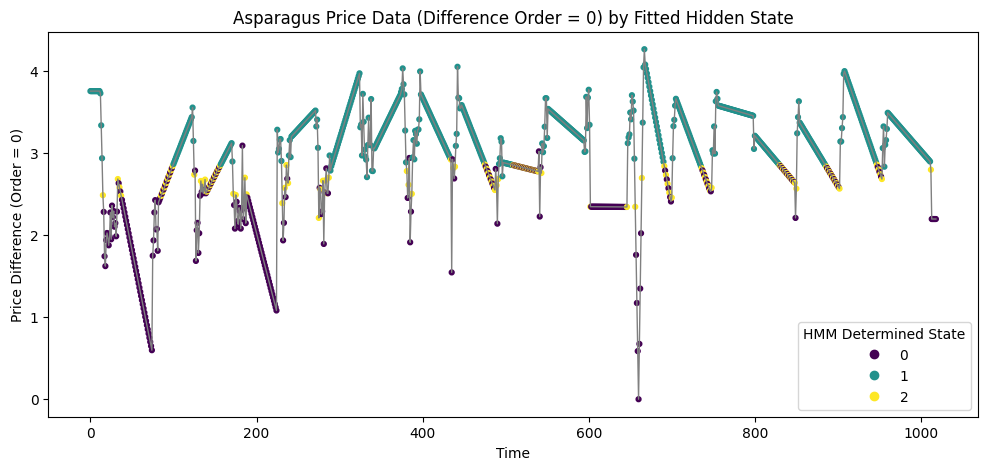

Frequency each each Asparagus State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      23  31  41  31  17  17  22  18  18  17  18  20
1      52  32  23  46  61  57  56  59  58  64  65  61
2      13  18  23  10   7   8   7   6   5   4   4   7


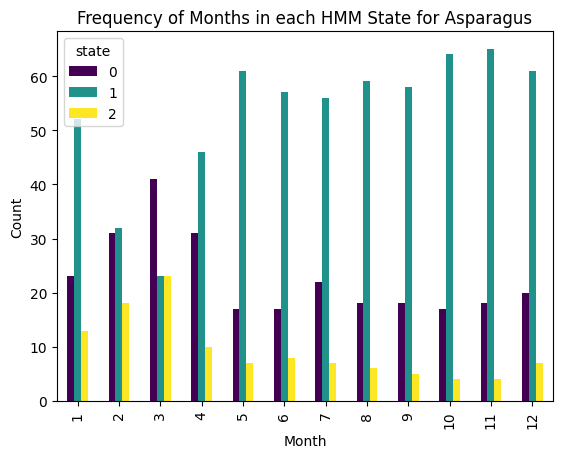

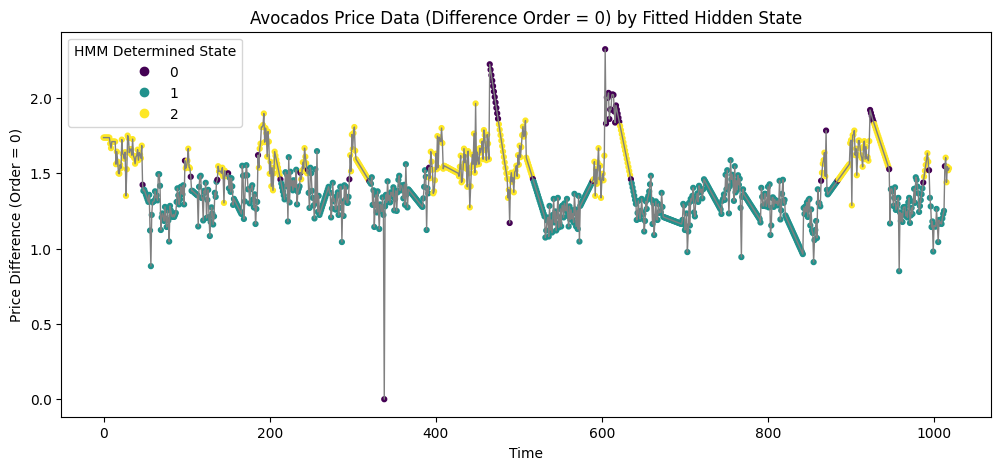

Frequency each each Avocados State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0       2   1   1   2   3   4   8   7  10   8   7   5
1      63  64  65  61  52  44  37  42  42  49  51  58
2      23  16  21  24  30  34  40  34  29  28  29  25


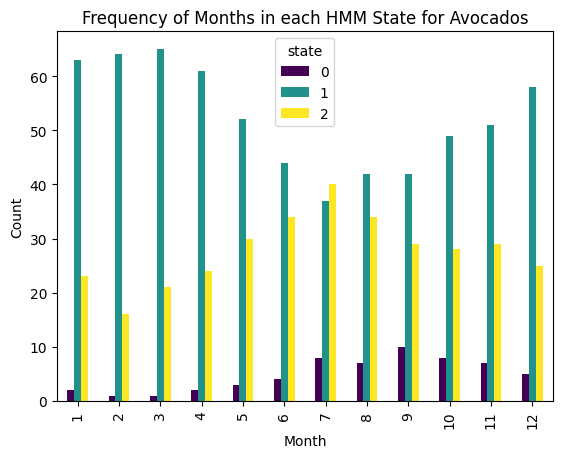

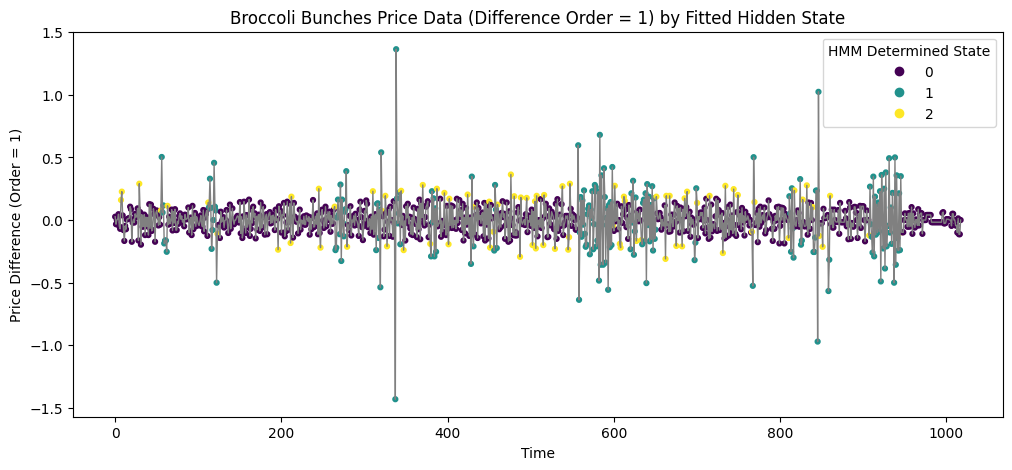

Frequency each each Broccoli Bunches State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      55  53  63  69  66  69  64  55  71  62  66  56
1      24  24  16  14  10   9   9  16   9  17  15  24
2       9   4   8   4   9   4  12  12   1   5   6   8


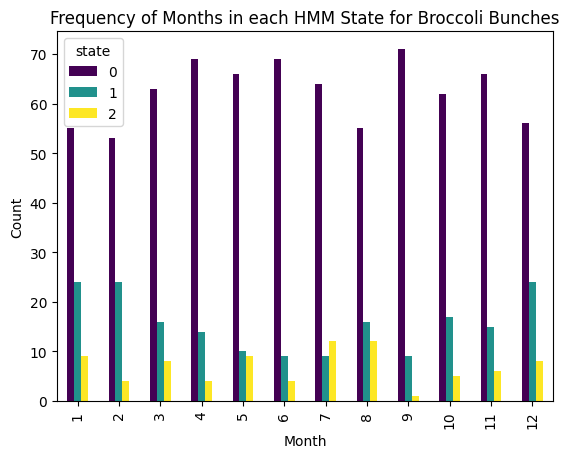

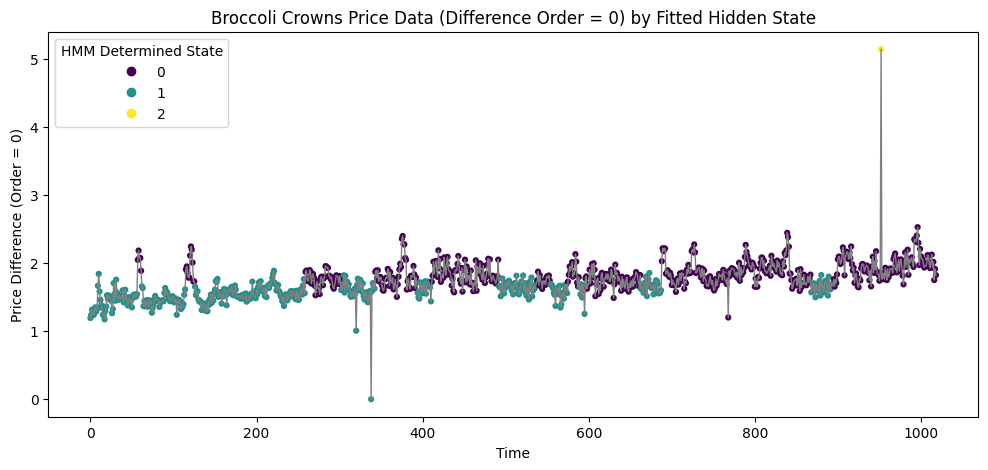

Frequency each each Broccoli Crowns State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0      55.0  55.0  58.0  57.0  56.0  50.0  48.0  36.0  34.0  41.0  48.0  53.0
1      33.0  26.0  28.0  30.0  29.0  32.0  37.0  47.0  47.0  44.0  39.0  35.0
2       NaN   NaN   1.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN


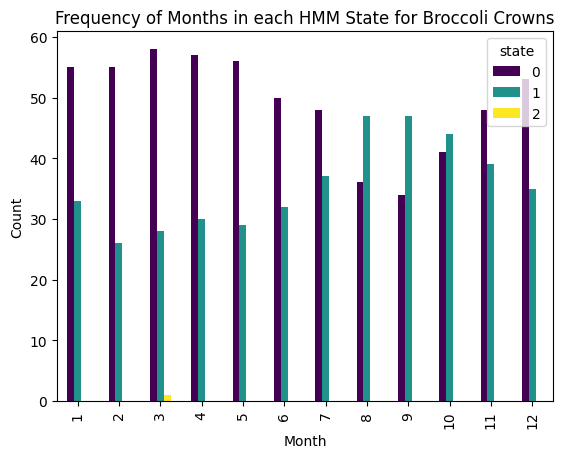

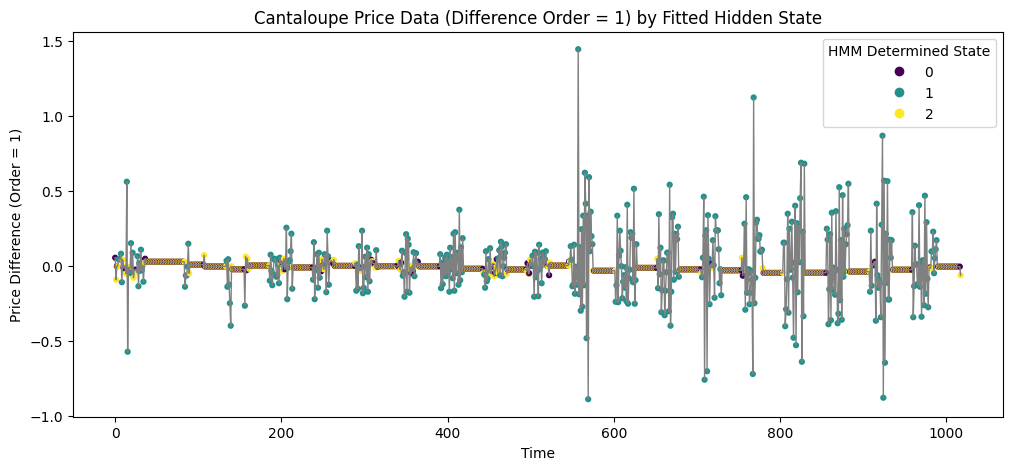

Frequency each each Cantaloupe State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0      43.0  39.0  45.0  44.0  24.0   6.0   8.0  12.0  11.0  13.0  21.0  39.0
1       NaN   2.0   3.0   NaN  30.0  68.0  68.0  56.0  54.0  62.0  37.0   4.0
2      45.0  40.0  39.0  43.0  31.0   8.0   9.0  15.0  16.0   9.0  29.0  45.0


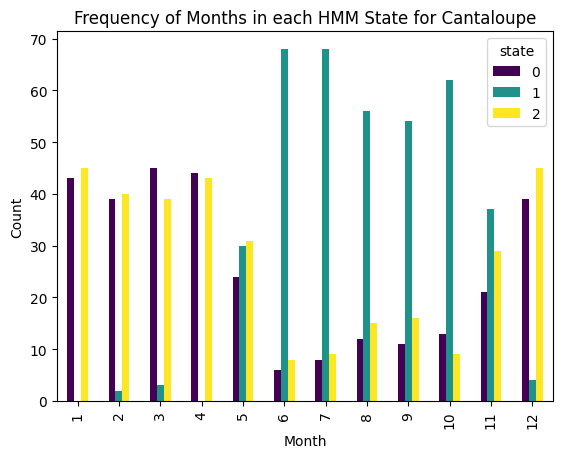

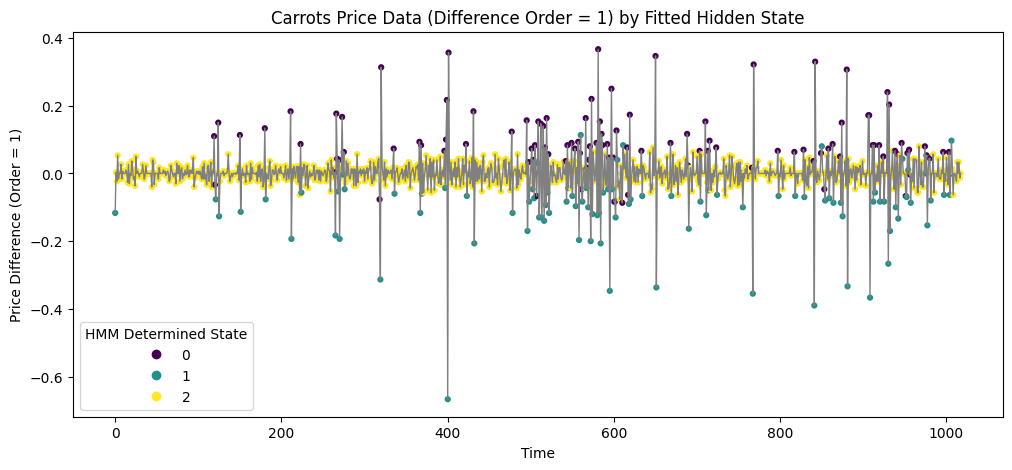

Frequency each each Carrots State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0       9  11   5  10  11   7  11   9  10  10   7  10
1       8   8   5   8   9   8   7  11   9   9   7   8
2      71  62  77  69  65  67  67  63  62  65  73  70


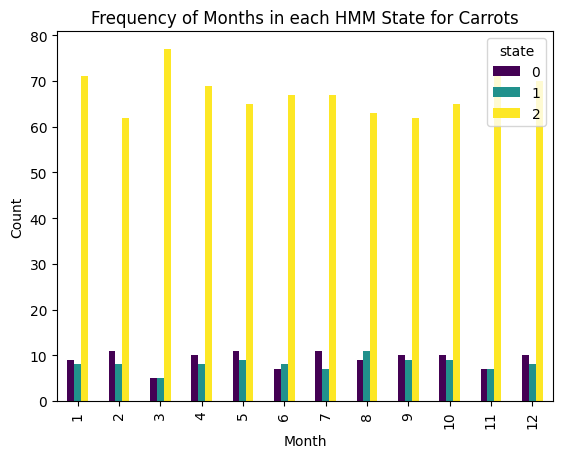

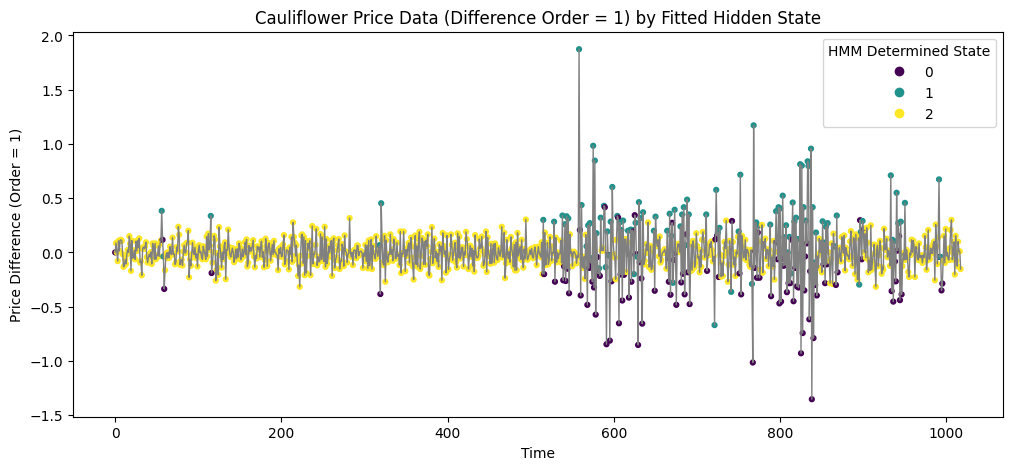

Frequency each each Cauliflower State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      14   6   8  10   7   3   7  10  10  14  11  17
1      14   6   7  10   8   4   4  11   6  12  12  14
2      60  69  72  67  70  75  74  62  65  58  64  57


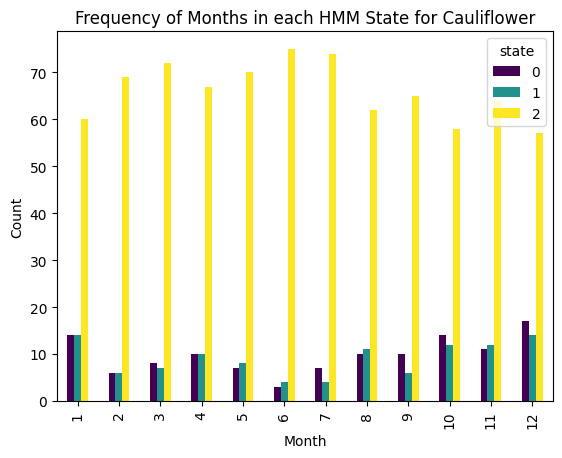

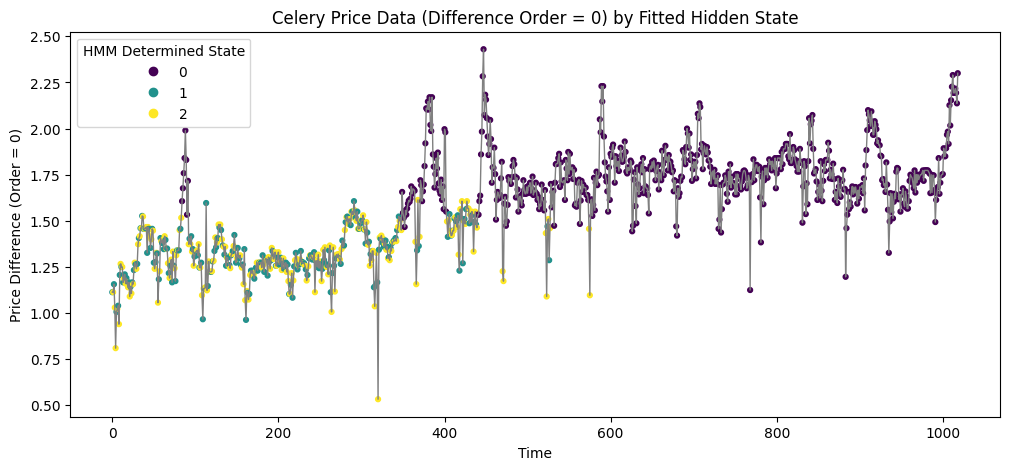

Frequency each each Celery State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      53  48  52  55  56  57  59  53  50  52  44  46
1      16  17  17  15  15  12  13  15  15  17  18  21
2      19  16  18  17  14  13  13  15  16  16  25  21


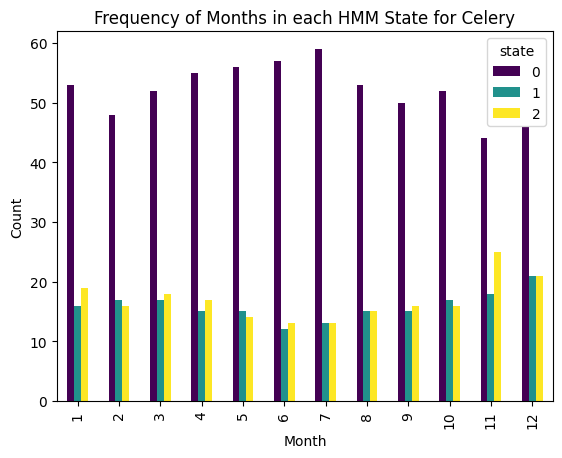

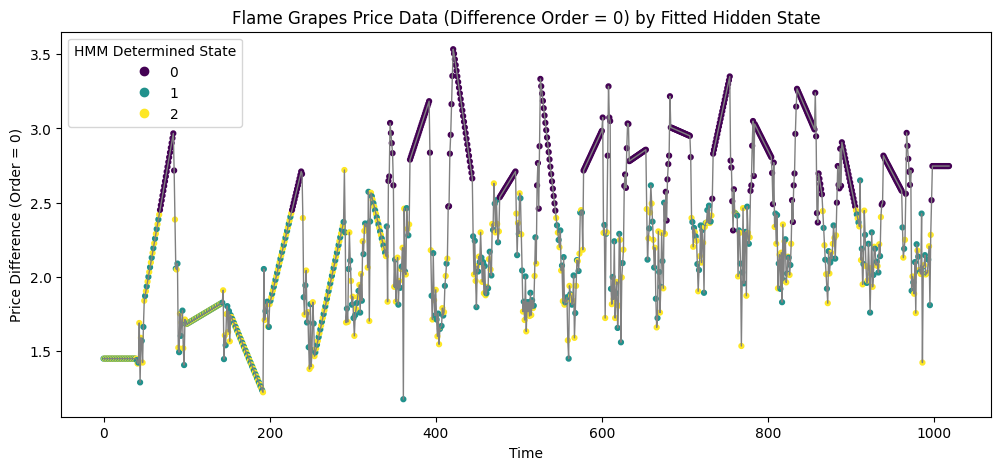

Frequency each each Flame Grapes State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0      57.0  56.0  65.0  63.0  48.0  13.0  15.0   NaN   NaN   2.0  26.0  47.0
1      15.0  12.0  11.0  11.0  19.0  31.0  36.0  40.0  42.0  42.0  29.0  19.0
2      16.0  13.0  11.0  13.0  18.0  38.0  34.0  43.0  39.0  41.0  32.0  22.0


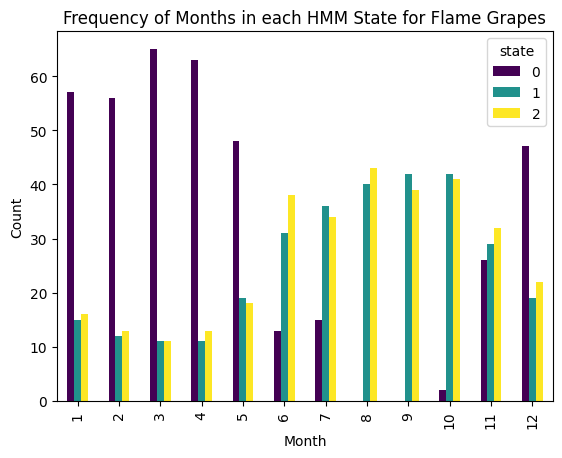

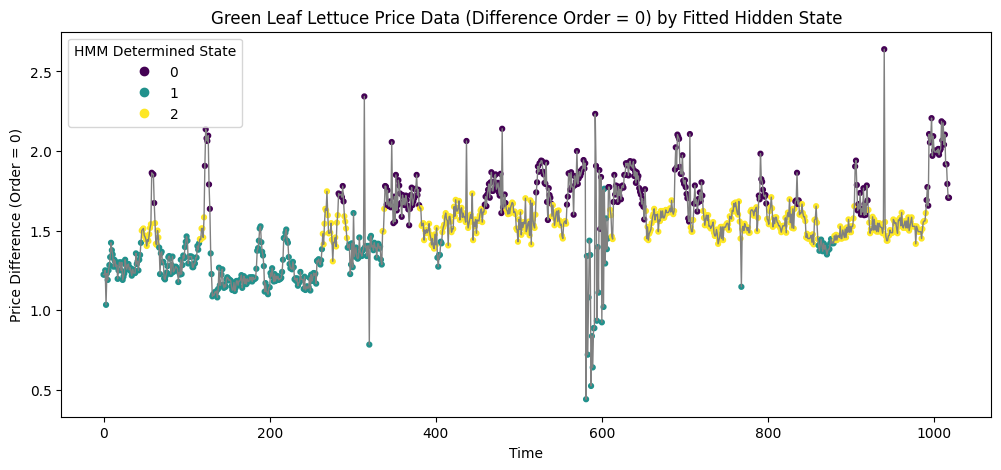

Frequency each each Green Leaf Lettuce State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      27  30  28  21  20  10  17  16  17  19  26  35
1      23  25  23  26  24  31  33  35  28  27  22  22
2      38  26  36  40  41  41  35  32  36  39  39  31


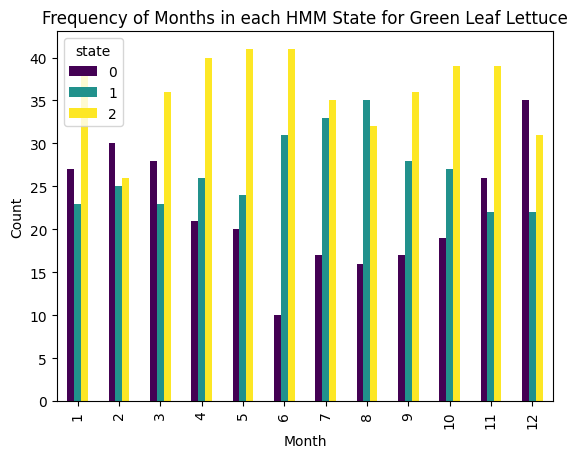

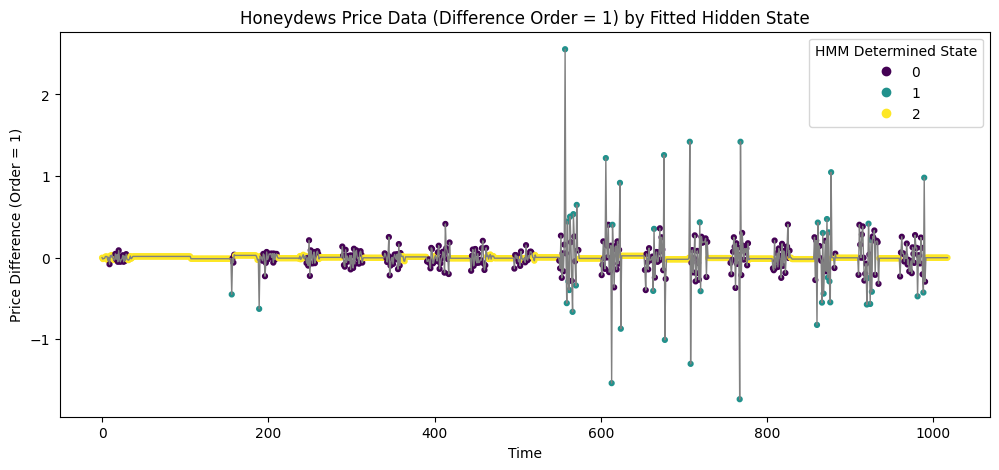

Frequency each each Honeydews State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0       1.0   2.0   4.0   5.0  20.0  56.0  60.0  53.0  56.0  52.0  22.0   NaN
1       NaN   NaN   NaN   NaN   NaN   5.0   5.0  14.0  11.0   8.0   4.0   NaN
2      87.0  79.0  83.0  82.0  65.0  21.0  20.0  16.0  14.0  24.0  61.0  88.0


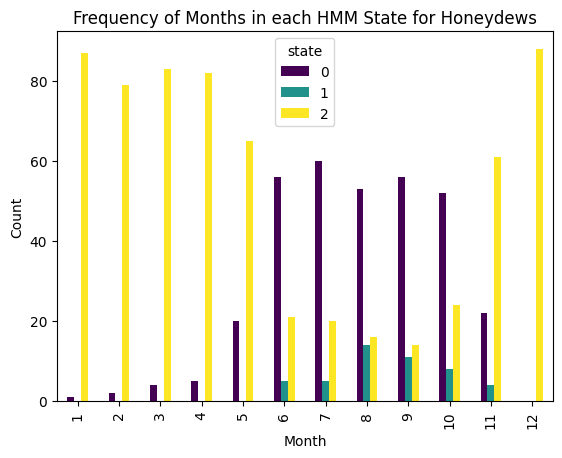

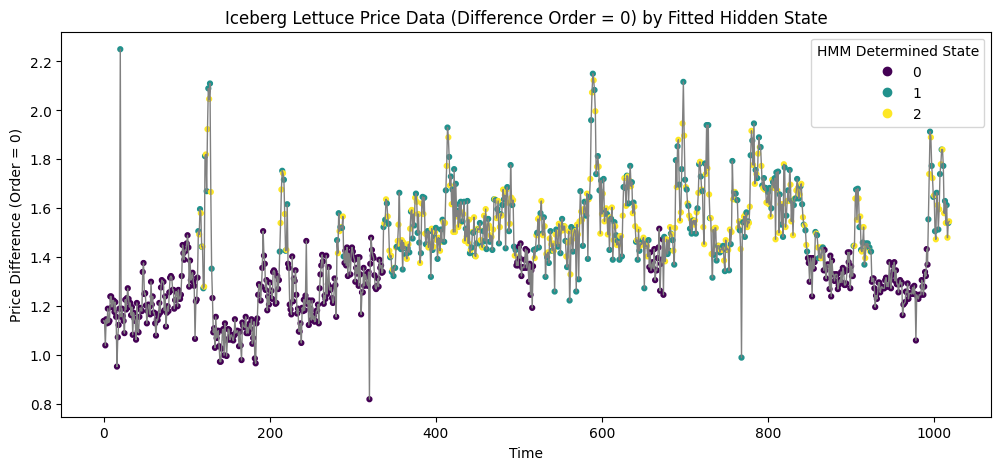

Frequency each each Iceberg Lettuce State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      33  33  32  31  31  37  44  43  50  46  38  34
1      26  24  28  26  28  21  19  21  14  17  24  27
2      29  24  27  30  26  24  22  19  17  22  25  27


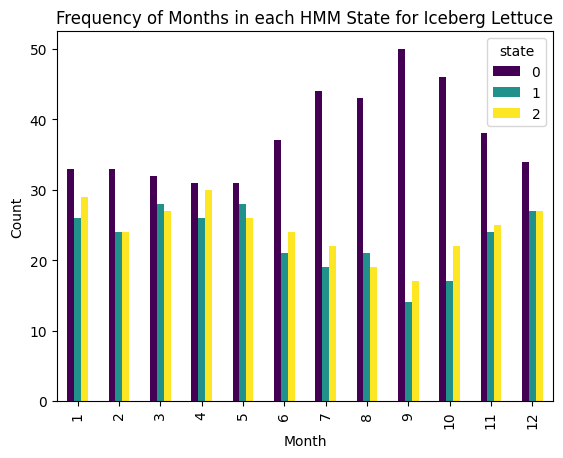

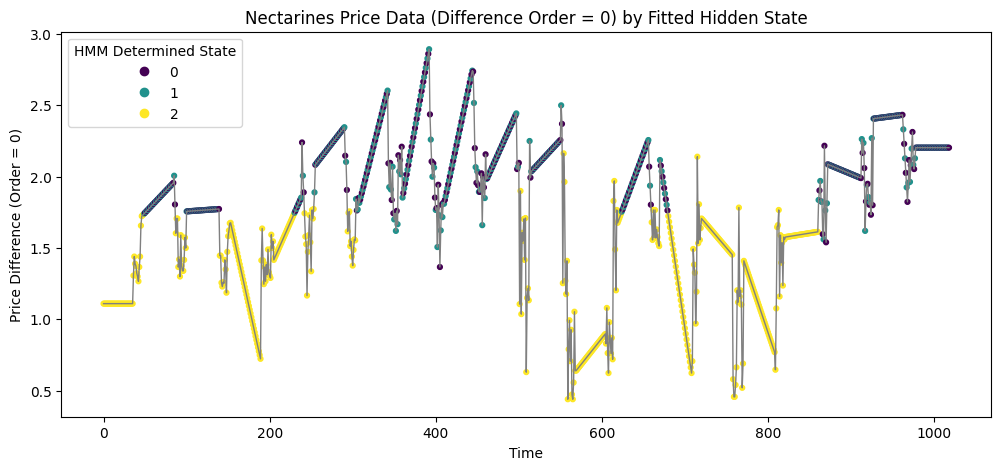

Frequency each each Nectarines State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      26  24  25  28  29  21  16  13  22  27  27  28
1      27  24  28  29  25  21  15  13  23  28  26  26
2      35  33  34  30  31  40  54  57  36  30  34  34


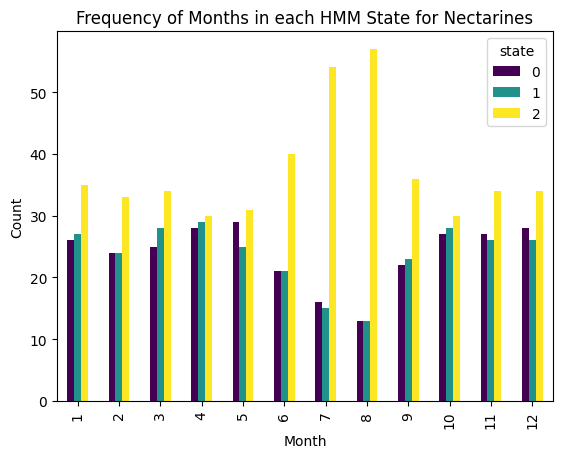

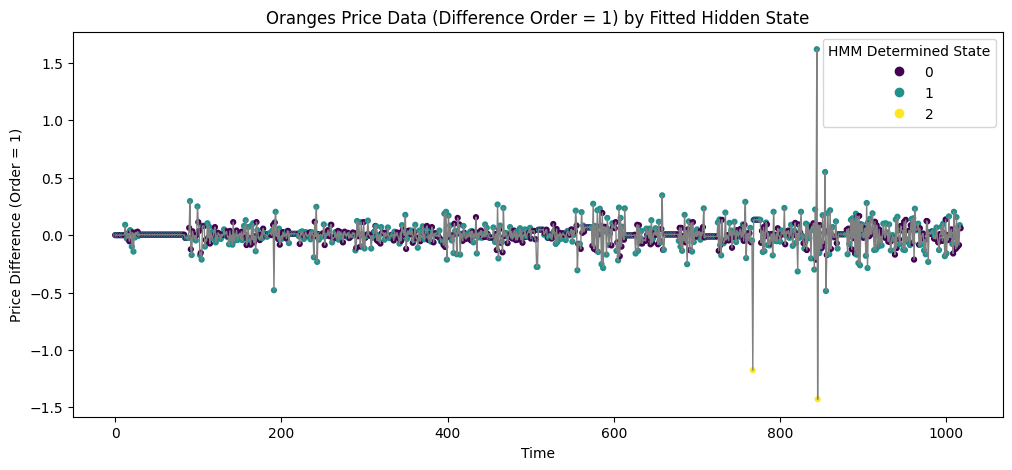

Frequency each each Oranges State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0      46.0  40.0  42.0  44.0  44.0  42.0  43.0  43.0  42.0  43.0  45.0  47.0
1      42.0  40.0  45.0  43.0  41.0  40.0  42.0  39.0  39.0  41.0  42.0  41.0
2       NaN   1.0   NaN   NaN   NaN   NaN   NaN   1.0   NaN   NaN   NaN   NaN


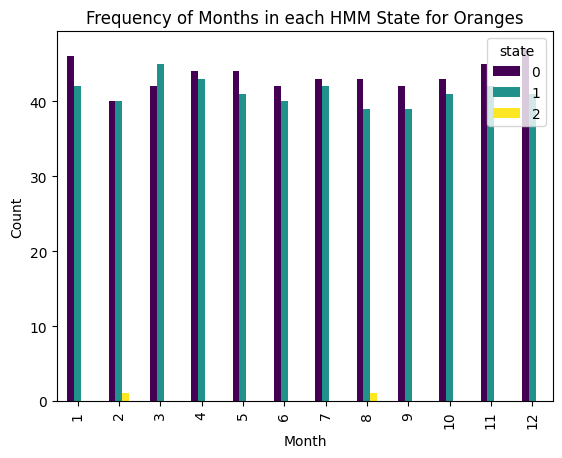

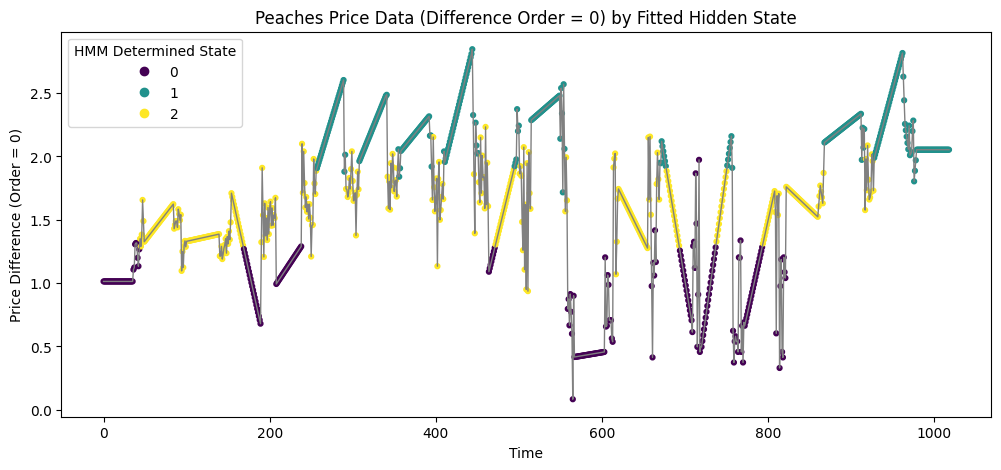

Frequency each each Peaches State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      22  21  22  21  20  21  24  25  11  20  27  20
1      36  32  33  38  40  20  10   8  24  41  34  36
2      30  28  32  28  25  41  51  50  46  24  26  32


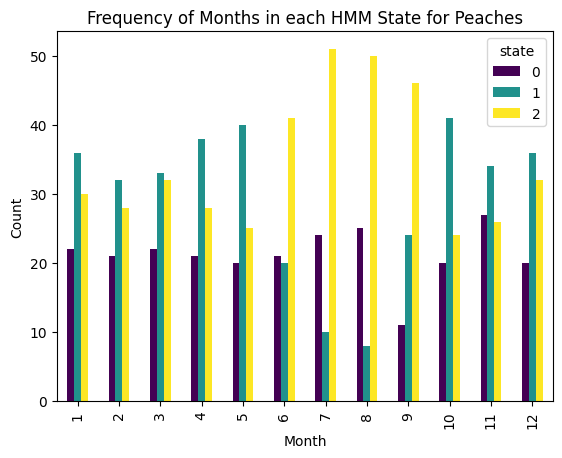

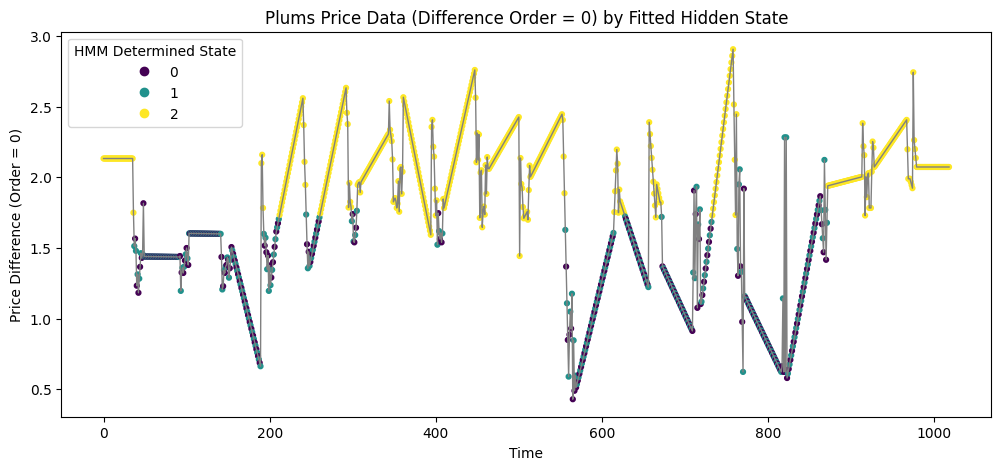

Frequency each each Plums State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      18  16  19  16  17  15  22  25  21  19  19  18
1      17  16  17  18  18  16  24  30  20  22  19  19
2      53  49  51  53  50  51  39  28  40  44  49  51


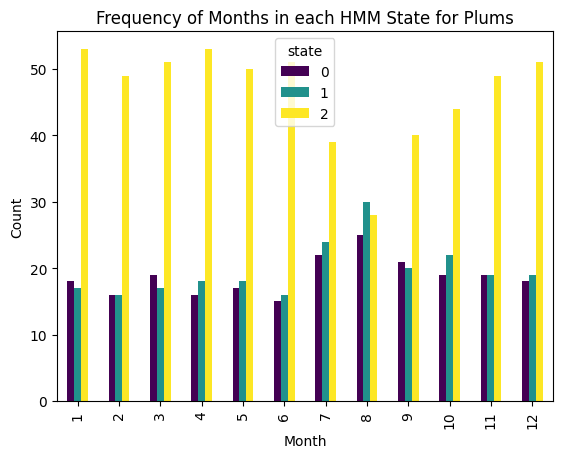

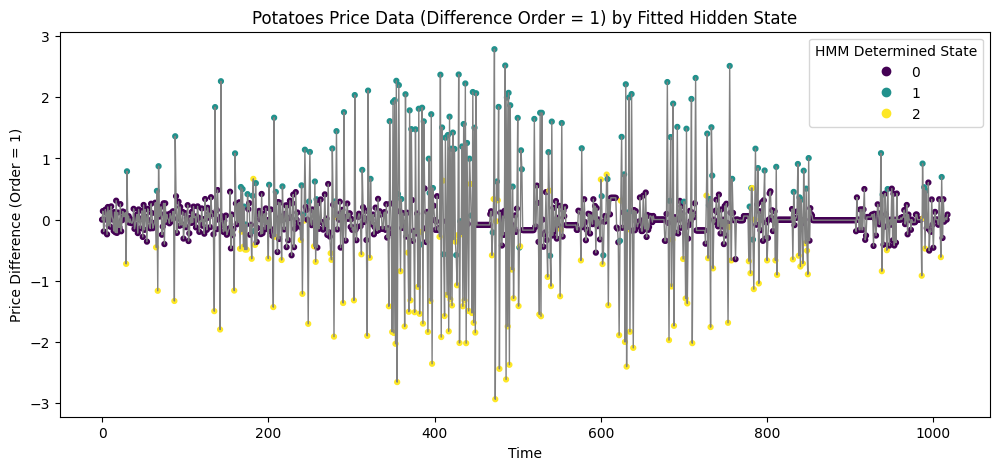

Frequency each each Potatoes State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      53  58  58  67  62  53  65  74  69  68  56  48
1      18  11  13  11   9  15  12   4   7   8  17  19
2      17  12  16   9  14  14   8   5   5   8  14  21


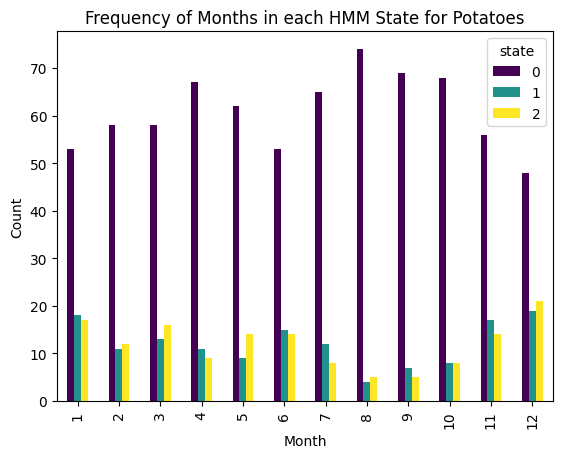

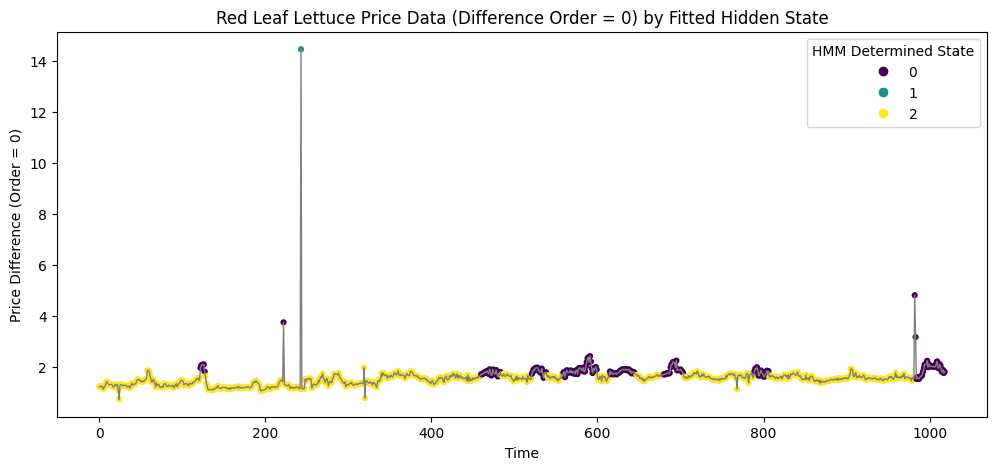

Frequency each each Red Leaf Lettuce State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0      30.0  29.0  28.0  17.0   8.0   NaN   NaN   6.0  15.0  18.0  24.0  26.0
1       NaN   NaN   NaN   NaN   NaN   1.0   NaN   NaN   NaN   NaN   NaN   NaN
2      58.0  52.0  59.0  70.0  77.0  81.0  85.0  77.0  66.0  67.0  63.0  62.0


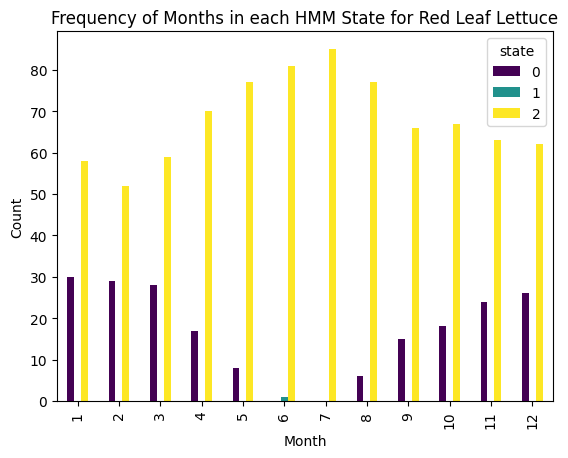

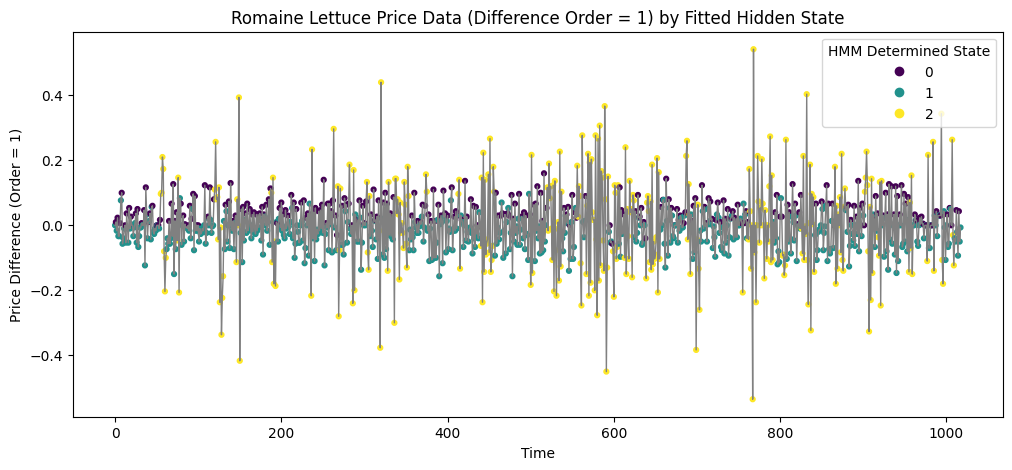

Frequency each each Romaine Lettuce State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      18  21  30  20  19  23  25  24  20  23  22  26
1      43  40  40  39  34  37  39  30  42  38  42  34
2      27  20  17  28  32  22  21  29  19  23  23  28


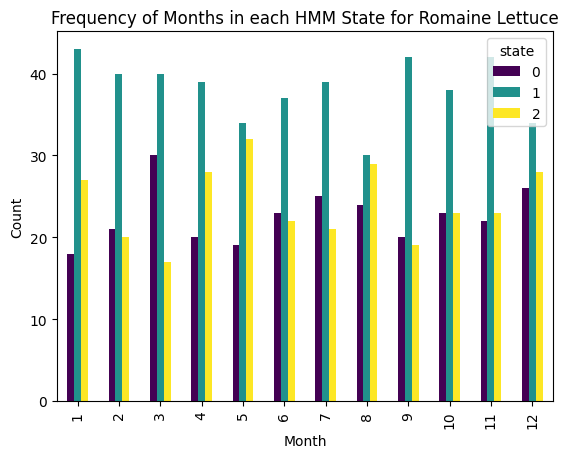

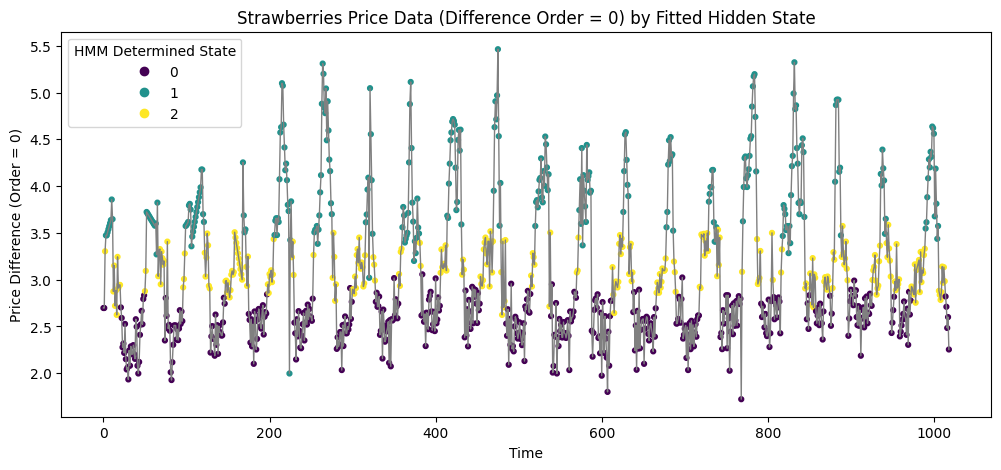

Frequency each each Strawberries State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0       1.0  21.0  62.0  75.0  80.0  82.0  81.0  41.0  15.0   6.0   NaN   NaN
1      56.0  25.0   NaN   NaN   NaN   NaN   NaN   4.0  14.0  30.0  72.0  82.0
2      31.0  35.0  25.0  12.0   5.0   NaN   4.0  38.0  52.0  49.0  15.0   6.0


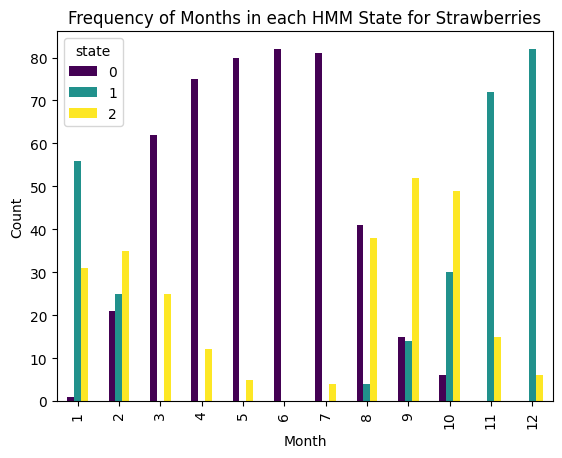

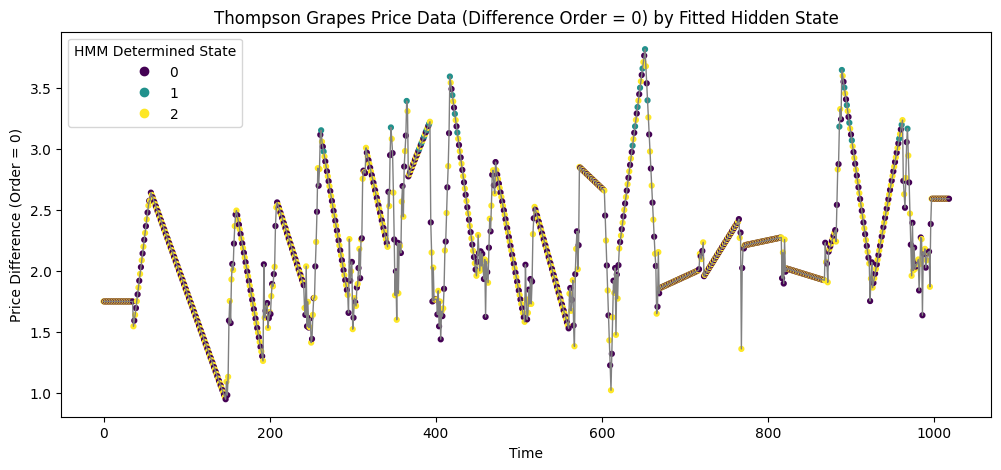

Frequency each each Thompson Grapes State corresponds to each month
month    1     2     3     4     5     6     7     8     9     10    11    12
state                                                                        
0      40.0  39.0  41.0  43.0  43.0  39.0  41.0  39.0  42.0  45.0  43.0  40.0
1       3.0   4.0   3.0   5.0   3.0   1.0   2.0   NaN   NaN   NaN   4.0   4.0
2      45.0  38.0  43.0  39.0  39.0  42.0  42.0  44.0  39.0  40.0  40.0  44.0


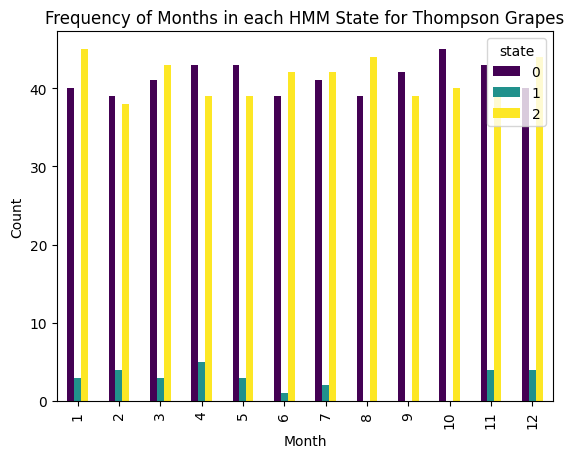

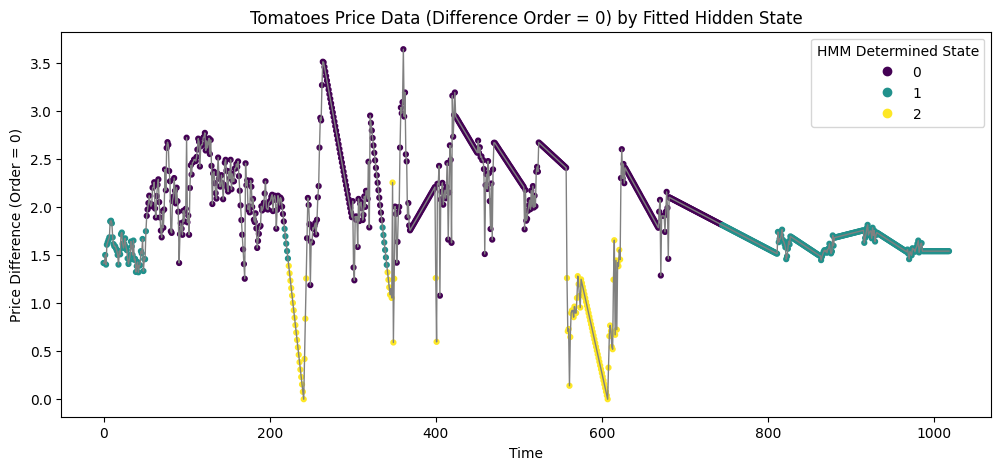

Frequency each each Tomatoes State corresponds to each month
month  1   2   3   4   5   6   7   8   9   10  11  12
state                                                
0      52  48  50  44  43  44  45  48  47  50  56  57
1      31  24  29  35  32  26  27  26  26  27  27  27
2       5   9   8   8  10  12  13   9   8   8   4   4


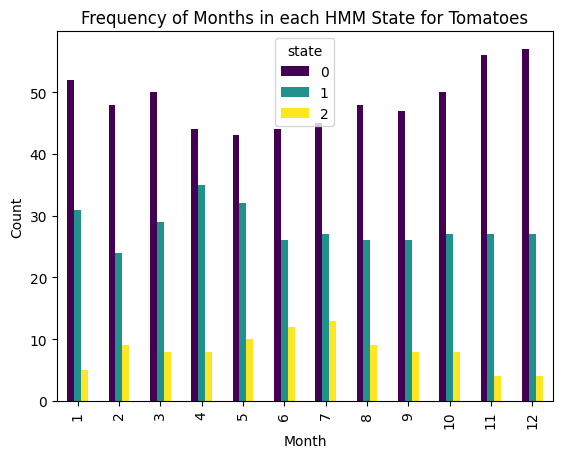

In [126]:
# plot each produce's data (differenced until covar stationary) with the HMM predicted state
pred_data = []
for produce in produce_names:

    # get dfference order and covar stationaed data
    d, produce_data = make_covar_stationary(produce_frame[produce_frame["productname"] == produce]["averageretail"].values)

    # fit hmm
    produce_hmm = hmm.GaussianHMM(n_components=3, covariance_type="full")
    produce_hmm.fit(produce_data.reshape(-1, 1))

    # predict with hmm 
    preds = produce_hmm.predict(produce_data.reshape(-1, 1))
    pred_data.append(preds)

    # plotting data by state
    plt.figure(figsize=(12, 5))
    plt.plot(produce_data, color="gray", lw=1)
    scatter = plt.scatter(np.arange(len(produce_data)), produce_data, c=preds, s=12, label="Hidden State", cmap="viridis")
    plt.title(f"{produce} Price Data (Difference Order = {d}) by Fitted Hidden State")
    plt.xlabel("Time")
    plt.ylabel(f"Price Difference (Order = {d})")
    plt.legend(*scatter.legend_elements(), title="HMM Determined State")
    plt.show()

    # analyzing state and month relationship
    state_df = produce_frame[produce_frame["productname"] == produce].iloc[d:].copy()  # want from dth row onwards since difference order d gets rid of first d data entries
    state_df["state"] = preds  # adding state column to dataframe
    state_df["date"] = pd.to_datetime(state_df["date"])  # converting date cokumn to pd dates
    state_df["month"] = state_df["date"].dt.month  # extracting month for each row and putting it in a column
    state_month_data = state_df.groupby(["state", "month"]).size().unstack() # gruping by hmm state and month with rows as states and columns as months

    # printing table counts for states vs months (states rows, months on columns)
    print(f"Frequency each each {produce} State corresponds to each month")
    print(state_month_data)

    state_month_data.T.plot(kind="bar", cmap="viridis")  
    plt.title(f"Frequency of Months in each HMM State for {produce}")
    plt.ylabel("Count")
    plt.xlabel("Month")
    plt.show()
    

In [ ]:
for produce in produce_names:
    produce_df = produce_data[""]